In [1]:
from pathlib import Path

import prism

from imagematerials.eol import eol_preprocess
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
)
from imagematerials.preprocessing import get_preprocessing_data

In [2]:
scenario_list = {"base":("SSP2",["base"])}

In [ ]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

all_output = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path("..", "data", "raw", "IMAGE_CircoMod", climate_scen)
    circular_economy_scenario_dirs = {
        scenario: scenario_base_path / scenario for scenario in circular_scen
    }

    bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), climate_policy_scenario_dir, circular_economy_scenario_dirs) 
    vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), climate_policy_scenario_dir, circular_economy_scenario_dirs)

    # TODO fix this for real in the future
    prep_data = vhc_sector.prep_data

    # target_materials = [
    # "Aluminium", "Brick", "Cement", "Concrete", 
    # "Copper", "Glass", "Steel", "Wood"
    # ]

    # prep_data['battery_materials'] = prep_data['battery_materials'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    # prep_data['battery_materials'] = prep_data['battery_materials'].reindex(material=target_materials)
    # prep_data['material_fractions'] = prep_data['material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    # prep_data['material_fractions'] = prep_data['material_fractions'].reindex(material=target_materials)
    # prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    # prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].reindex(material=target_materials)

    vhc_sector = Sector('vehicles', prep_data)

    prep_eol = eol_preprocess(Path("..", "data", "raw"), circular_economy_scenario_dirs)
    eol_sector = Sector(name="eol", data = prep_eol)

    factory = ModelFactory(
    [bld_sector, vhc_sector, eol_sector], complete_timeline
    ).add(GenericStocks, ["buildings", "vehicles"]
    ).add(GenericMaterials,  "vehicles"
    # ).add(Maintenance, "vehicles"
    ).add(MaterialIntensities, "buildings",
    # ).add(EndOfLife, "eol", input_sources={
    # "outflow_by_cohort_materials": ["vehicles", "buildings"],
    # "collection": "eol",
    # "reuse": "eol",
    # "recycling": "eol"}
)
    model = factory.finish()

    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)

    # all_output[scen_id] = {
    #     "inflow_materials": [model.vehicles["inflow_materials"], model.buildings["inflow_materials"]],
    #     "reusable_materials": model.eol["reusable_materials"],
    #     "recyclable_materials": model.eol["recyclable_materials"]
    # }
    print(f"Finished {scen_id}")

implemented 'base' for Residential Buildings


c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\indexing.py:1566: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


Mismatch in coordinates with dimension 'Time' with data array 'population' having different coordinates than previously assumed in '['stocks']'.New: [np.int64(1700), np.int64(1701), np.int64(1702), np.int64(1703), np.int64(1704), np.int64(1705), np.int64(1706), np.int64(1707), np.int64(1708), np.int64(1709), np.int64(1710), np.int64(1711), np.int64(1712), np.int64(1713), np.int64(1714), np.int64(1715), np.int64(1716), np.int64(1717), np.int64(1718), np.int64(1719), np.int64(1720), np.int64(1721), np.int64(1722), np.int64(1723), np.int64(1724), np.int64(1725), np.int64(1726), np.int64(1727), np.int64(1728), np.int64(1729), np.int64(1730), np.int64(1731), np.int64(1732), np.int64(1733), np.int64(1734), np.int64(1735), np.int64(1736), np.int64(1737), np.int64(1738), np.int64(1739), np.int64(1740), np.int64(1741), np.int64(1742), np.int64(1743), np.int64(1744), np.int64(1745), np.int64(1746), np.int64(1747), np.int64(1748), np.int64(1749), np.int64(1750), np.int64(1751), np.int64(1752), np

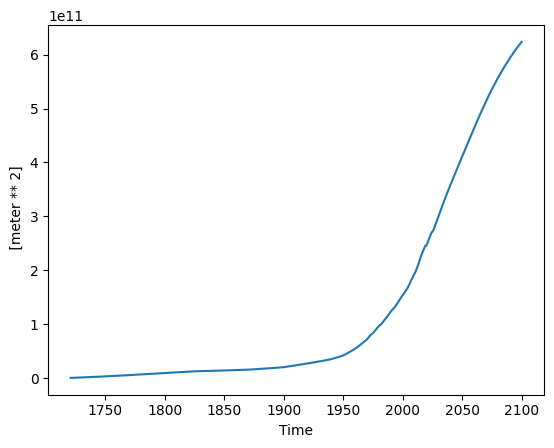

In [4]:
model.buildings.get('stocks').sum(['Type', 'Region']).plot()


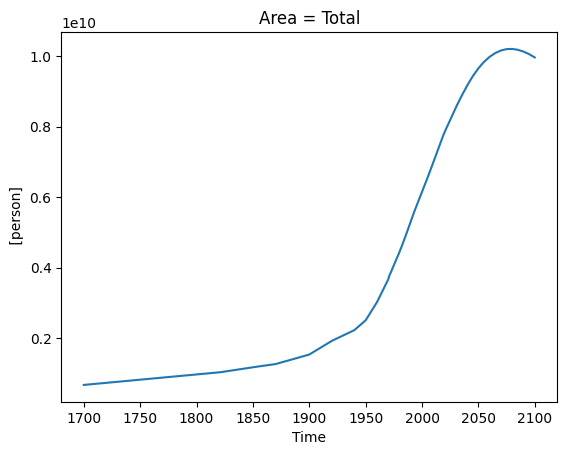

In [5]:
bld_sector.prep_data.get('population').sel(Area = 'Total').sum('Region').plot()

In [6]:
vhc_sector.prep_data.keys()

dict_keys(['lifetimes', 'battery_materials', 'battery_shares', 'material_fractions', 'battery_weights', 'stocks', 'maintenance_material_fractions', 'knowledge_graph', 'weights', 'set_unit_flexible'])

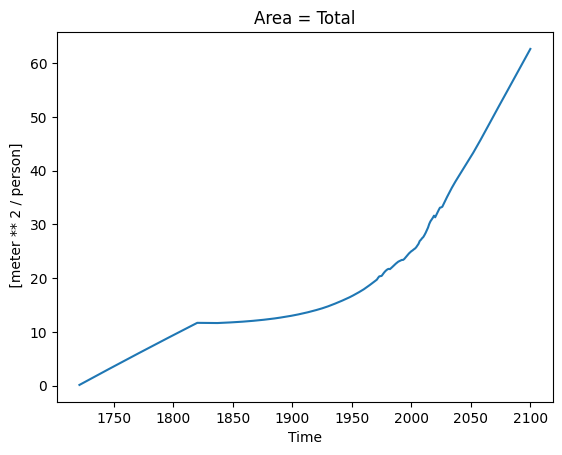

In [7]:
# floorspace per capita
per_cap_floorspace = model.buildings.get('stocks').sum(['Type', 'Region']) / bld_sector.prep_data.get('population').sel(Area = 'Total').sum('Region')
per_cap_floorspace.plot()

In [8]:
stocks = vhc_sector.prep_data.get('stocks')
print(stocks.pint.units)

count


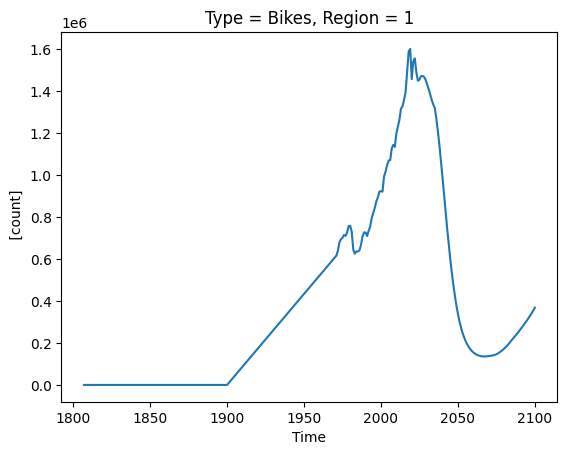

In [12]:
model.vehicles.get('stocks').sel(Region ='1', Type = 'Bikes').plot()